In [1]:
import numpy as np

def cptAb(n, A, b):
  n2 = 2 * n
  A = np.reshape(A, (n2, n2))
  b = np.reshape(b, (n2, 1))
  top = np.c_[A, b]
  bottom = np.c_[np.zeros((1, n2)), [0]]
  Ab = np.r_[top, bottom]
  return Ab

def cptx01(n, x0):
  x0 = np.reshape(x0, (2 * n, 1))
  return np.r_[x0, [[1]]]

def cptFormulaXAb(Ab, t, x01):
    from scipy.linalg import expm
    """
    Compute the formula for x(t) = e^(At) * x0 + b using the matrix exponential.
    
    Parameters:
    n : size of the matrix
    Ab : augmented matrix containing A and b
    t : time variable
    x01 : initial condition vector
    
    Returns:
    The computed value of x(t).
    """
    # Compute the matrix exponential
    exp_At = expm(Ab * t)  # Placeholder for actual matrix exponential computation
    return exp_At @ x01

def cptPois(Ab):
    """
    Compute the points of interest (pois) based on the eigenvalues of the augmented matrix Ab
    """
    eigvals = np.linalg.eigvals(Ab)
    alphaVec = np.unique(-np.sort(-np.abs(eigvals.imag), ), sorted=True)
    alphaVecNonZero = alphaVec[alphaVec > 0]
    pois = np.zeros(4 * len(alphaVecNonZero))
    for i in range(len(alphaVecNonZero)):
        temp = np.pi / alphaVecNonZero[i]
        pois[4 * i] = 0.5 * temp
        pois[4 * i + 1] = temp
        pois[4 * i + 2] = 1.5 * temp
        pois[4 * i + 3] = 2 * temp
    return np.sort(pois)

def findMinRootBisection(n, A, b, x0, maxIter=300, tolerance=1e-10):
    """
    Find the minimum root of a e^At * x0 + b = 0 using the bisection method.
    
    Parameters:
    A : exponential matrix coefficients
    b : constant term
    x0 : initial guess for the root
    minTime : minimum time to consider for the root
    
    Returns:
    The minimum root found.
    """
    Ab = cptAb(n, A, b)
    pois = cptPois(Ab)
    print("pois:", pois)
    
    x01 = cptx01(n, x0)
    lowerBound = 1e-12
    upperBound = 0.1
    negativeDepthExists = False
    for poi in pois:
      x1t = cptFormulaXAb(Ab, poi, x01)
      if np.any(x1t[:n] < 0):
        upperBound = poi
        negativeDepthExists = True
        break
      else:
        lowerBound = poi
    print("lowerBound:", lowerBound, "upperBound:", upperBound)
    if not negativeDepthExists:
      print("No negative depth found in pois, returning minTime")
      return -1
    m = (lowerBound + upperBound) / 2
    i = 0
    for i in range(maxIter):
      m = (lowerBound + upperBound) / 2
      x1t = cptFormulaXAb(Ab, m, x01)
      if np.any(np.abs(x1t[:n]) < tolerance) and not np.any(x1t[:n] < -tolerance):
        break
      if not np.any(x1t[:n] < 0):
        lowerBound = m
      else:
        upperBound = m
    if i == maxIter:
      print(i, maxIter)
      m = -1
    return m

from scipy.linalg import expm
# minTime: 5.91013e-05 b: [0, 0, 11.5631, 74.1144] A: [0, 0, 10000, 0, 0, 0, 0, 10000, -126606, -6.31995, -25321.1, -1.26399, -6.31995, -125946, -1.26399, -25189.2] x0: [0, 0.92195, 0.274991, 0.0921651]
n = 3
A = [0, 0, 0, 10000, 0, 0, 0, 0, 0, 0, 10000, 0, 0, 0, 0, 0, 0, 10000, -128482, -14.8786, -16.0424, -64241.2, -7.43932, -8.02119, -14.8786, -124860, -6.52619, -7.43932, -62430, -3.26309, -16.0424, -6.52619, -128481, -8.02119, -3.26309, -64240.4]
b = [0, 0, 0, 518.729, 576.15, 517.475]
x0 = [0.0040653, 8.64578, 0.00409006, -4.24972e-05, -0.0521689, -9.39328e-05]
tc = findMinRootBisection(n, A, b, x0, 2000)
Ab = cptAb(n, A, b)
x01 = cptx01(n, x0)
n = 3
A = [0, 0, 0, 10000, 0, 0, 0, 0, 0, 0, 10000, 0, 0, 0, 0, 0, 0, 10000, -139096, -17.8518, -8.72151, -69547.8, -8.92589, -4.36075, -17.8518, -128098, -10.6906, -8.92589, -64048.8, -5.34529, -8.72151, -10.6906, -138274, -4.36075, -5.34529, -69136.8]
b = [0, 0, 0, 409.096, -17.1745, 391.63]
x0 = [0.00294159, 0, 0.00283271, -5.00871e-06, -0.00243912, -4.65992e-06]
tc = findMinRootBisection(n, A, b, x0, 2000)
Ab = cptAb(n, A, b)
x01 = cptx01(n, x0)
print("tc: ", tc)
print("Ab: ", Ab)
print("x01: ", x01)
print(cptFormulaXAb(Ab, tc, x01))


pois: [9.48564794e-05 9.87176002e-05 9.87557069e-05 1.89712959e-04
 1.97435200e-04 1.97511414e-04 2.84569438e-04 2.96152800e-04
 2.96267121e-04 3.79425918e-04 3.94870401e-04 3.95022828e-04]
lowerBound: 9.875570692893275e-05 upperBound: 0.00018971295889685198
pois: [9.82865493e-05 1.14633363e-04 1.16520037e-04 1.96573099e-04
 2.29266726e-04 2.33040075e-04 2.94859648e-04 3.43900089e-04
 3.49560112e-04 3.93146197e-04 4.58533452e-04 4.66080149e-04]
lowerBound: 1e-12 upperBound: 9.828654928148676e-05
tc:  3.9291673982586495e-12
Ab:  [[ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+04  0.00000e+00
   0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+04
   0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
   1.00000e+04  0.00000e+00]
 [-1.39096e+05 -1.78518e+01 -8.72151e+00 -6.95478e+04 -8.92589e+00
  -4.36075e+00  4.09096e+02]
 [-1.78518e+01 -1.28098e+05 -1.06906e+01 -8.92589e+00 -6.40488e+04
  -5.34529e+00 

Eq(x(t), 0.00049 - 4.00527682652007e-5*exp(-99999.7999996*t) + 0.000202320768265201*exp(-0.2000004000016*t)) 4.0052688159504*exp(-99999.7999996*t) - 4.04642345816712e-5*exp(-0.2000004000016*t)


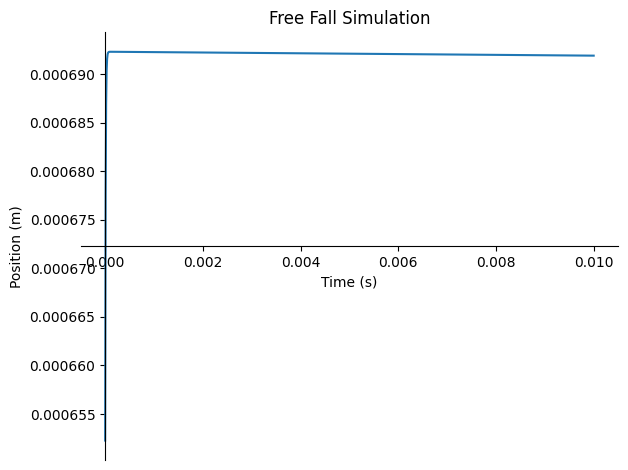

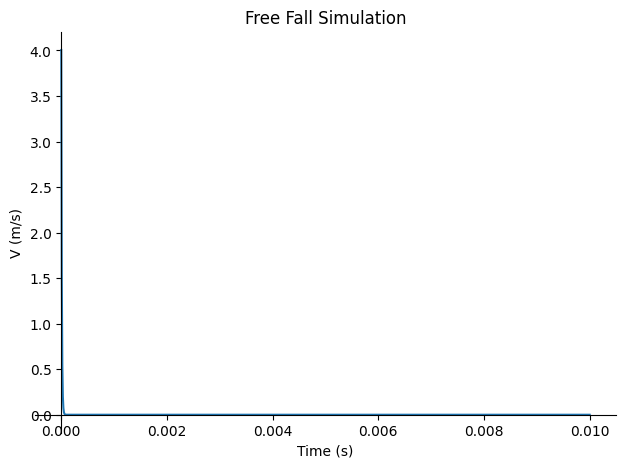

In [ ]:
import sympy as sp
t = sp.symbols('t')
x = sp.Function('x')(t)
diff_eq = sp.Eq(sp.Derivative(x, t, 2) + 1e5 * sp.Derivative(x, t) + 2e4 * x, 9.8)
x0 = [0.000652268, -3.31293e-05]
solnp = sp.dsolve(diff_eq, x, ics={x.subs(t, 0): x0[0], sp.Derivative(x, t).subs(t, 1): x0[1]})
print(solnp, sp.diff(solnp.rhs, t))

sp.plot(solnp.rhs, (t, 0, 0.01), title='Free Fall Simulation', xlabel='Time (s)', ylabel='Position (m)', show=True)
sp.plot(sp.diff(solnp.rhs, t), (t, 0, 0.01), title='Free Fall Simulation', xlabel='Time (s)', ylabel='V (m/s)', show=True)

Eq(x(t), 0.00049 - 4.00527682652007e-5*exp(-99999.7999996*t) + 0.000202320768265201*exp(-0.2000004000016*t)) 4.0052688159504*exp(-99999.7999996*t) - 4.04642345816712e-5*exp(-0.2000004000016*t)


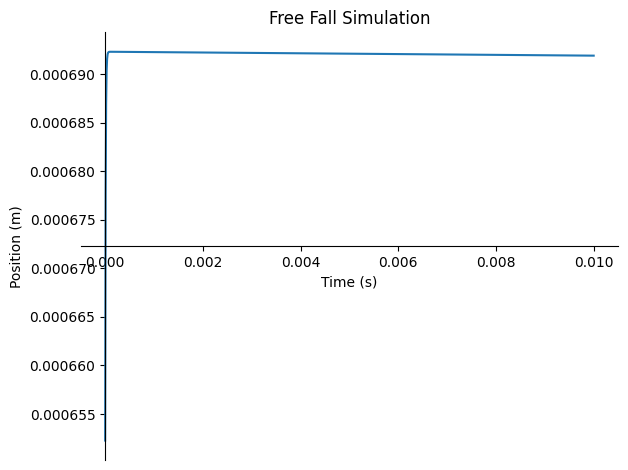

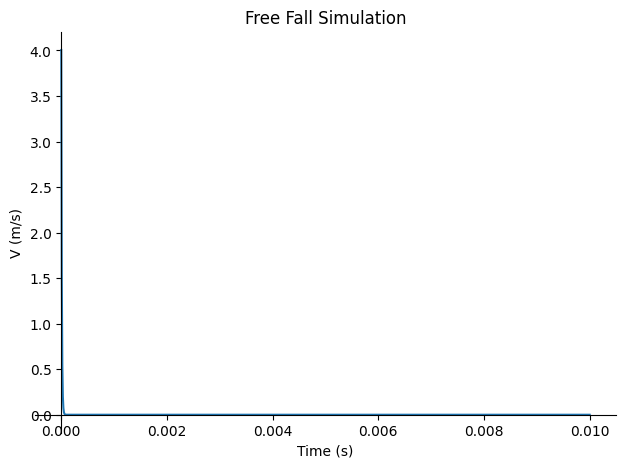

In [ ]:
import sympy as sp
t = sp.symbols('t')
x = sp.Function('x')(t)
diff_eq = sp.Eq(sp.Derivative(x, t, 2) + 1e5 * sp.Derivative(x, t) + 2e5 * x, 9.8)
x0 = [0.0000652268, -3.31293e-05]
solnp = sp.dsolve(diff_eq, x, ics={x.subs(t, 0): x0[0], sp.Derivative(x, t).subs(t, 1): x0[1]})
print(solnp, sp.diff(solnp.rhs, t))

sp.plot(solnp.rhs, (t, 0, 0.01), title='Free Fall Simulation', xlabel='Time (s)', ylabel='Position (m)', show=True)
sp.plot(sp.diff(solnp.rhs, t), (t, 0, 0.01), title='Free Fall Simulation', xlabel='Time (s)', ylabel='V (m/s)', show=True)

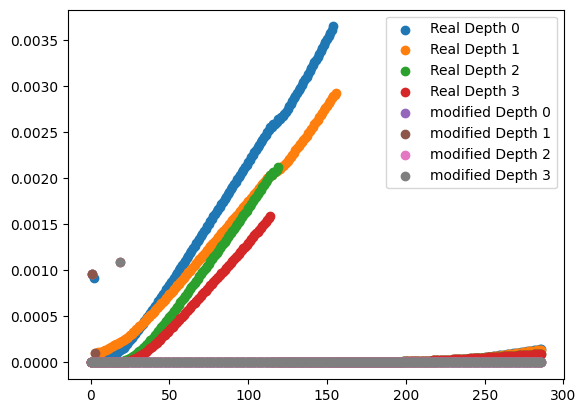

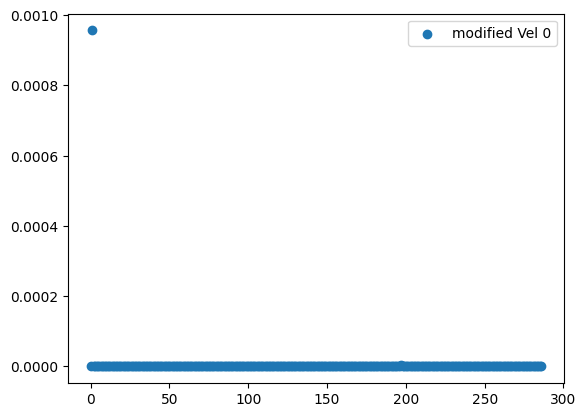

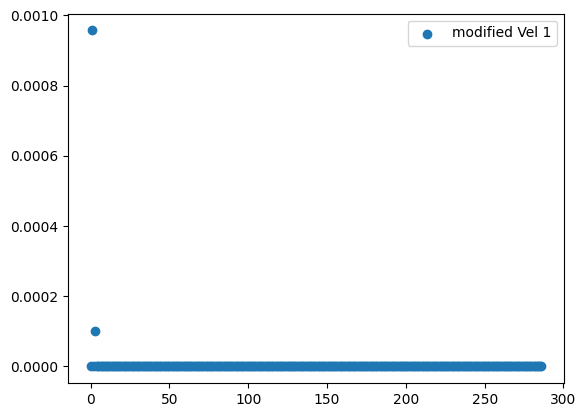

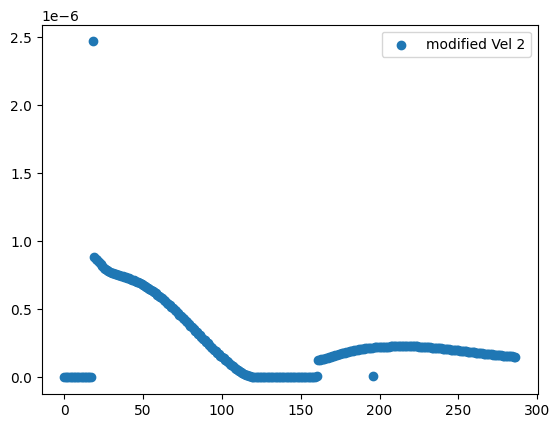

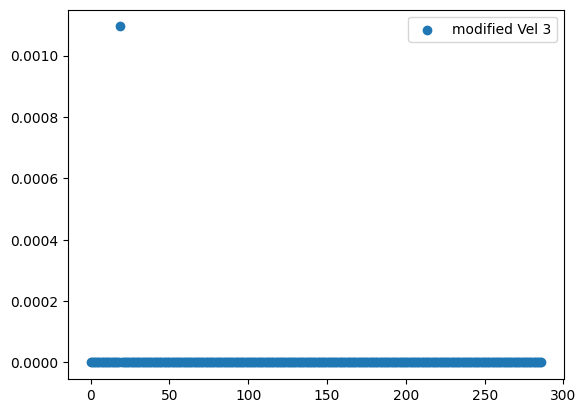

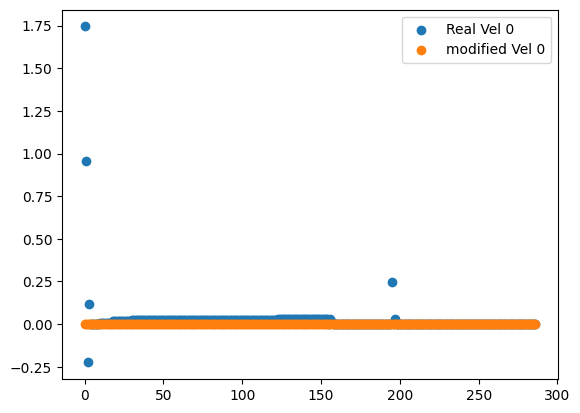

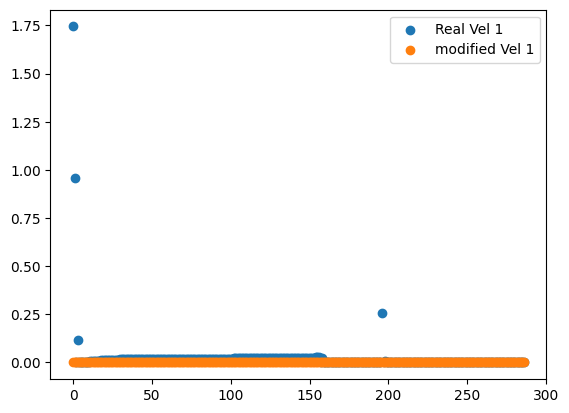

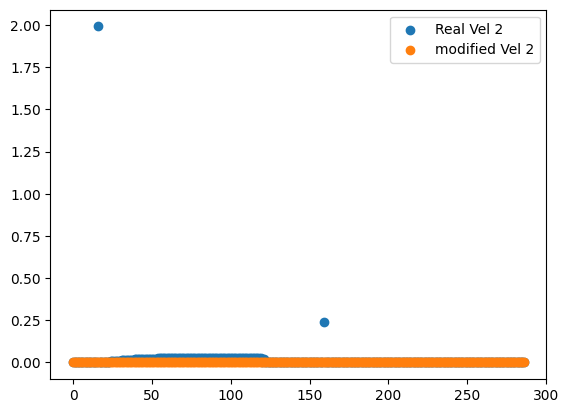

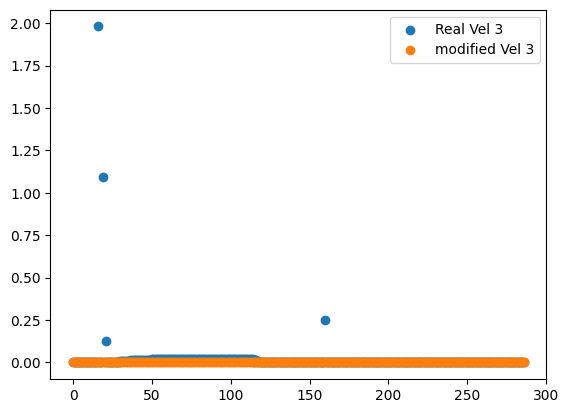

In [6]:
import json
from matplotlib import pyplot as plt
with open('D:/code/sire/contact_solver_result.json', 'r') as contact_solver_log:
    contactLog = json.load(contact_solver_log)

realContactState = contactLog["realContactState"]
modifiedContactState = contactLog["modifiedContactState"]
start = 0
size = len(realContactState)
# size = 10
end = start + size
depthData = np.zeros((8, size))
velData = np.zeros((8, size))
t = np.arange(start, end, 1)
for i in t:
  numContacts = len(realContactState[i]);
  for j in range(numContacts):
    idx1 = int(realContactState[i][j]["pair"]["id_A"]) + int(realContactState[i][j]["pair"]["id_B"]) - 1
    idx2 = int(modifiedContactState[i][j]["pair"]["id_A"]) + int(modifiedContactState[i][j]["pair"]["id_B"]) - 1
    depthData[idx1, i-start] = realContactState[i][j]["depth"]
    velData[idx1, i-start] = realContactState[i][j]["velocity"]
    depthData[idx2 + 4, i-start] = modifiedContactState[i][j]["depth"]
    velData[idx2 + 4, i-start] = modifiedContactState[i][j]["depth"]

plt.scatter(t, depthData[0, :], label='Real Depth 0')
plt.scatter(t, depthData[1, :], label='Real Depth 1')
plt.scatter(t, depthData[2, :], label='Real Depth 2')
plt.scatter(t, depthData[3, :], label='Real Depth 3')
plt.scatter(t, depthData[4, :], label='modified Depth 0')
plt.scatter(t, depthData[5, :], label='modified Depth 1')
plt.scatter(t, depthData[6, :], label='modified Depth 2')
plt.scatter(t, depthData[7, :], label='modified Depth 3')
plt.legend()
plt.show()

# plt.scatter(t, velData[0, :], label='Real Vel 0')
plt.scatter(t, velData[4, :], label='modified Vel 0')
plt.legend()
plt.show()
# plt.scatter(t, velData[1, :], label='Real Vel 1')
plt.scatter(t, velData[5, :], label='modified Vel 1')
plt.legend()
plt.show()
# plt.scatter(t, velData[2, :], label='Real Vel 2')
plt.scatter(t, velData[6, :], label='modified Vel 2')
plt.legend()
plt.show()
# plt.scatter(t, velData[3, :], label='Real Vel 3')
plt.scatter(t, velData[7, :], label='modified Vel 3')
plt.legend()
plt.show()

plt.scatter(t, velData[0, :], label='Real Vel 0')
plt.scatter(t, velData[4, :], label='modified Vel 0')
plt.legend()
plt.show()
plt.scatter(t, velData[1, :], label='Real Vel 1')
plt.scatter(t, velData[5, :], label='modified Vel 1')
plt.legend()
plt.show()
plt.scatter(t, velData[2, :], label='Real Vel 2')
plt.scatter(t, velData[6, :], label='modified Vel 2')
plt.legend()
plt.show()
plt.scatter(t, velData[3, :], label='Real Vel 3')
plt.scatter(t, velData[7, :], label='modified Vel 3')
plt.legend()
plt.show()